# Figure XX - Hb9-RFP reporter

In [1]:
import rushd as rd
import pandas as pd
import numpy as np
import scipy.stats
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib
from textwrap import wrap
from statannotations.Annotator import Annotator
#from statannot import add_stat_annotation
import itertools

import warnings
warnings.filterwarnings("ignore",category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)#, module="seaborn._oldcore")

sns.set_theme(style="ticks",font_scale=1)


In [2]:
experimentdir1 = rd.datadir/'data'/'attune'/'Brittany_attune'/'2025.11.10_iMN_flow_stain'
experimentdir2 = rd.datadir/'data'/'attune'/'Brittany_attune'/'2026.07.06_Hb9-Syn_reporters'
outputdir = rd.rootdir/'output'/'Figure_XX_Hb9'

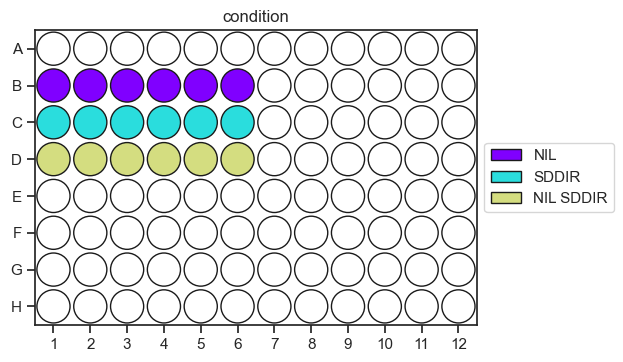

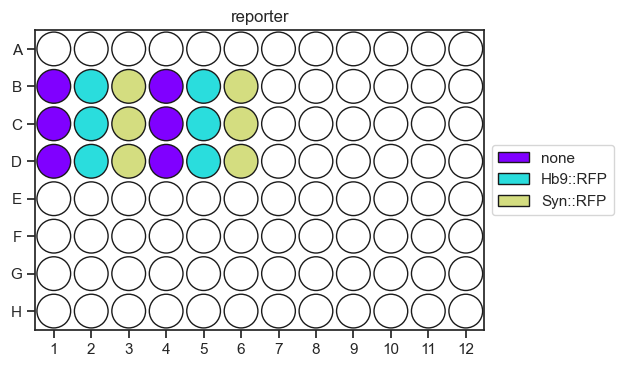

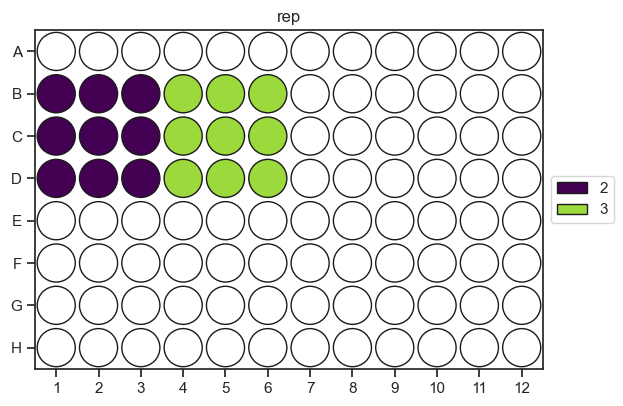

In [3]:
rd.plot.plot_well_metadata(experimentdir2/'metadata.yaml')


# Load Data

In [4]:
data_columns = ['GFP-A','RFP-A']

plates = pd.DataFrame({
        'data_path': [experimentdir1/f'csv']           + [experimentdir2/f'csv'],
        'yaml_path': [experimentdir1/f'metadata2.yaml'] + [experimentdir2/f'metadata.yaml'],
    })
df = rd.flow.load_groups_with_metadata(plates, columns=data_columns)
df['condition2'] = df['condition'] + ' ' + df['reporter']


Get rid of negative values

In [5]:
plot_df = df[df[data_columns].gt(0).all(axis=1)]

RFP Gate

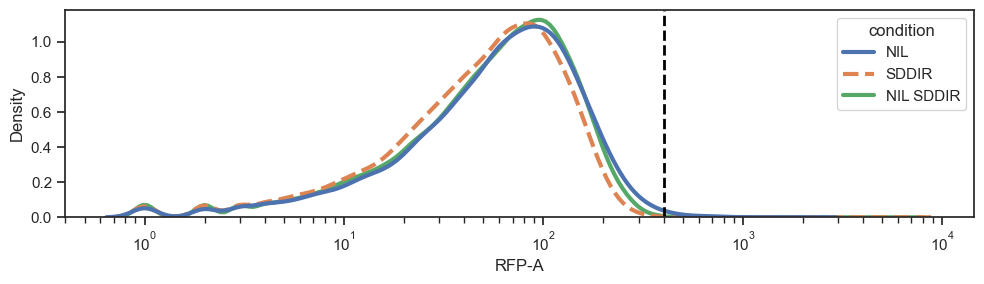

In [6]:
RFP_gate = 400

slice = plot_df[(plot_df.reporter.isin(['none','Hb9::RFP','Syn::RFP']))]
slice = slice[(slice['rep'] == 3) & (slice.reporter == 'none')]
# Plot gate
#fig = plt.figure(figsize=(10,3))
fig, ax = plt.subplots(figsize=(10, 3))

sns.kdeplot(ax=ax,data=slice,x='RFP-A',hue='condition',log_scale=True,common_norm=False,linewidth=3)
plt.axvline(x=RFP_gate,linestyle='--',color='black',linewidth=2)

#plt.legend()
lss = reversed(['-', '-', '-', '--','--', '-', '-', '--','-'])
handles = ax.legend_.legend_handles[::-1]
for line, ls, handle in zip(ax.lines, lss, handles):
    line.set_linestyle(ls)
    handle.set_ls(ls)
#sns.move_legend(ax, loc='upper left', bbox_to_anchor=(1,1), frameon=False)
plt.tight_layout()
plt.show()

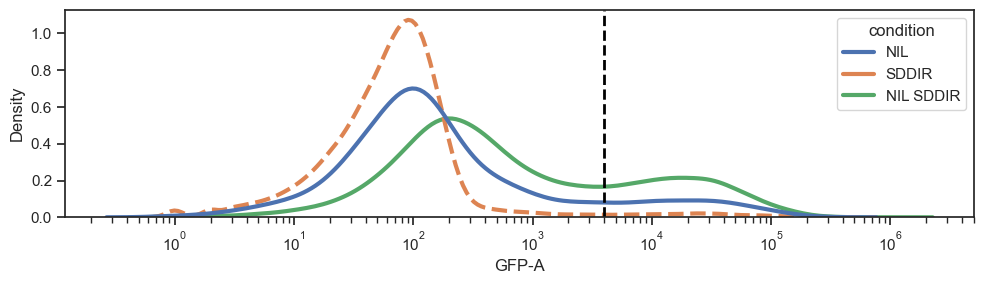

In [7]:
iMN_gate = 4 * 10**3

slice = plot_df[(plot_df.reporter.isin(['none']))]
slice = slice[(slice['rep'] == 1)]

# Plot gate
#fig = plt.figure(figsize=(10,3))
fig, ax = plt.subplots(figsize=(10, 3))

sns.kdeplot(ax=ax,data=slice,x='GFP-A',hue='condition',log_scale=True,common_norm=False,linewidth=3)
plt.axvline(x=iMN_gate,linestyle='--',color='black',linewidth=2)

#plt.legend()
lss = reversed(['-', '-', '-', '--','--', '-', '-', '--','-'])
#handles = ax.legend_.legend_handles[::-1]
for line, ls, handle in zip(ax.lines, lss, handles):
    line.set_linestyle(ls)
    handle.set_ls(ls)
#sns.move_legend(ax, loc='upper left', bbox_to_anchor=(1,1), frameon=False)
plt.tight_layout()
plt.show()

In [8]:
# Get rid of SDDIR GFP+ cells that are contamination from NIL SDDIR condition during flow

df = df[~((df['condition'] == 'SDDIR') & (df['GFP-A'] > 400))]
plot_df = df[df[data_columns].gt(0).all(axis=1)]

# Plotting Functions

In [9]:
def jointplot(x,y,data,filename,height=3,hue=None,hue_order=None,
              plottitle='',palette='viridis',type='scatter',x_gate=None,y_gate=None,xlim=(1,5*10**7),ylim=(1,5*10**7)):

    g = sns.JointGrid(data=data, x=x, y=y, hue=hue,ratio=3, hue_order=hue_order,space=0,
                    xlim=xlim,ylim=ylim,height=height)
    
    # plot histograms in marginals
    g = g.plot_marginals(sns.kdeplot, fill=True, alpha=0.1, common_norm=False, log_scale=True, palette=palette)
    ax = g.ax_joint

    if 'scatter' in type:
        g.plot_joint(sns.scatterplot,s=3,hue_order=hue_order,palette=palette) #scatter plot in main graph
    if 'contour' in type:
        g = g.plot_joint(sns.kdeplot, alpha=0.8,palette=palette, common_norm=True,levels=12) #contour plot in main graph 
    if 'filled' in type:
        for cond in hue_order:
            g = g.plot_joint(sns.kdeplot, data=data[data[hue]==cond],alpha=0.5,fill=True,palette=palette) #filled contour plot in main graph 

    # Add in gates (optional)
    if x_gate:
        ax.axvline(x_gate, 0, 1, color='grey',linestyle='--')
    if y_gate:
        ax.axhline(y_gate, 0, 1, color='grey',linestyle='--')

    plt.title(plottitle)
    plt.subplots_adjust(left=0.2, right=0.95, top=0.9, bottom=0.25) # make all plots have the same area
    sns.move_legend(g.ax_joint, loc='upper left', bbox_to_anchor=(1.35,1), frameon=False)
    g.savefig(outputdir/str(filename + '.svg'),dpi=300)


# Plot Results

In [10]:
savedict = {'Hb9::RFP':'Hb9-RFP', 'Syn::RFP':'Syn-RFP'}

**Figure XX - HB9-RFP**

In [ ]:
lim_dict = {'GFP-A':[1,1*10**6],
            'RFP-A':[1,4*10**5]}

reporter_order = ['Hb9::RFP','Syn::RFP']
ycat_order = ['RFP-A','RFP-A']

for reporter, y in zip(reporter_order,ycat_order):
        condition2_order = ['SDDIR ' + reporter,'NIL SDDIR ' + reporter,'SDDIR none']
        palette = {condition2_order[0]:"#65a1a9",
                condition2_order[1]:"#b76161",
                condition2_order[2]:"#555555"}    
        file = savedict[reporter] + '_all-reps'
        x= 'GFP-A'
        slice = plot_df[(plot_df.condition2.isin(condition2_order))]
        jointplot(x,y,slice.sample(20000),filename=file,height=3,hue='condition2',hue_order=condition2_order,
                        plottitle=reporter,palette=palette,type='contour',x_gate=iMN_gate,y_gate=None,xlim=lim_dict[x],ylim=lim_dict[y])

        plottitle = f'Figure_XX_{reporter}-reporter.svg'
        plt.savefig(rd.outfile(outputdir/plottitle),bbox_inches='tight')

Plots by rep

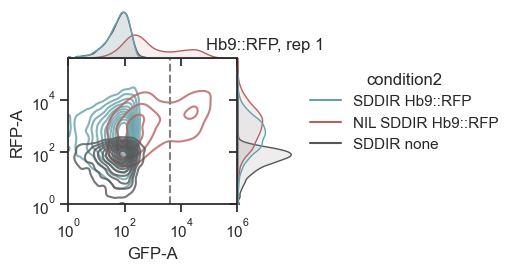

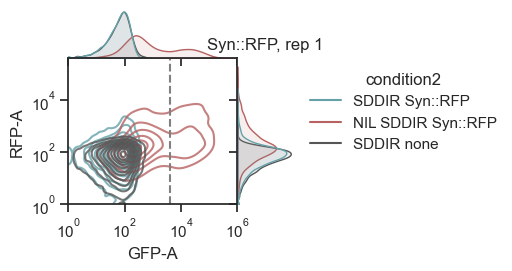

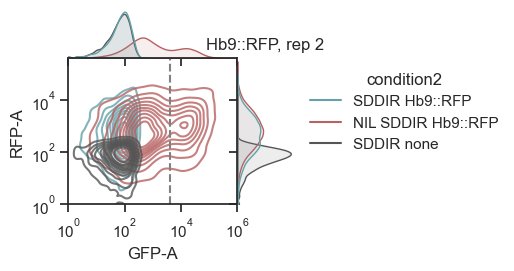

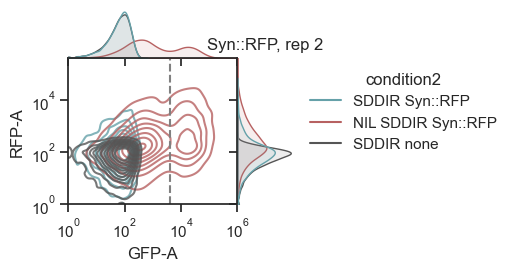

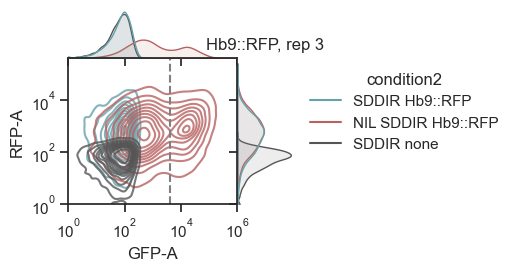

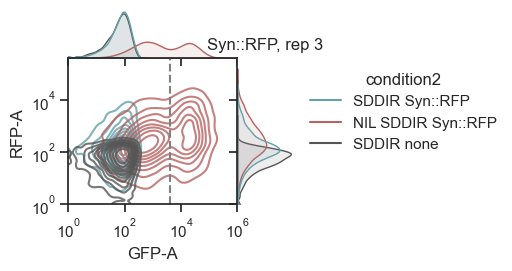

In [13]:
lim_dict = {'GFP-A':[1,1*10**6],
            'RFP-A':[1,4*10**5]}

reporter_order = ['Hb9::RFP','Syn::RFP']
ycat_order = ['RFP-A','RFP-A']

for rep in [1,2,3]:
        for reporter, y in zip(reporter_order,ycat_order):
                condition2_order = ['SDDIR ' + reporter,'NIL SDDIR ' + reporter,'SDDIR none']
                palette = {condition2_order[0]:"#65a1a9",
                        condition2_order[1]:"#b76161",
                        condition2_order[2]:"#555555"}    
                file = savedict[reporter] + '_rep' + str(rep)
                x= 'GFP-A'
                slice = plot_df[(plot_df.condition2.isin(condition2_order)) & (plot_df.rep == rep)]
                jointplot(x,y,slice.sample(20000),filename=file,height=3,hue='condition2',hue_order=condition2_order,
                                plottitle=reporter + ', rep ' + str(rep),palette=palette,type='contour',x_gate=iMN_gate,y_gate=None,xlim=lim_dict[x],ylim=lim_dict[y])